In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from src.features.rfm import RFMAnalyzer, create_additional_features

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

np.random.seed(42)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv('../data/processed/cleaned_transactions.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Dataset loaded: {len(df):,} transactions")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

df.head()

Dataset loaded: 400,916 transactions
Unique customers: 4,312
Date range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00


In [3]:
analyzer = RFMAnalyzer()

rfm = analyzer.calculate_rfm(
    df, 
    customer_col='Customer ID',
    date_col='InvoiceDate',
    revenue_col='Revenue',
    invoice_col='Invoice'
)

print(f"RFM data created for {len(rfm):,} customers")
print(f"\nReference date for recency: {analyzer.reference_date}")

rfm.head(10)

RFM data created for 4,312 customers

Reference date for recency: 2010-12-10 20:01:00


,Customer ID,Recency,Frequency,Monetary
0,12346.00,165,11,372.86
1,12347.00,3,2,1323.32
2,12348.00,74,1,222.16
3,12349.00,43,3,2671.14
4,12351.00,11,1,300.93
5,12352.00,11,2,343.80
6,12353.00,44,1,317.76
7,12355.00,203,1,488.21
8,12356.00,16,3,3560.30
9,12357.00,24,2,12079.99


In [4]:
print("RFM Statistics:\n")
rfm[['Recency', 'Frequency', 'Monetary']].describe()

RFM Statistics:



,Recency,Frequency,Monetary
count,4312.00,4312.00,4312.00
mean,91.17,4.46,2040.41
std,96.86,8.17,8911.76
min,1.00,1.00,2.95
25%,18.00,1.00,307.19
50%,53.00,2.00,701.62
75%,136.00,5.00,1714.93
max,374.00,205.00,349164.35


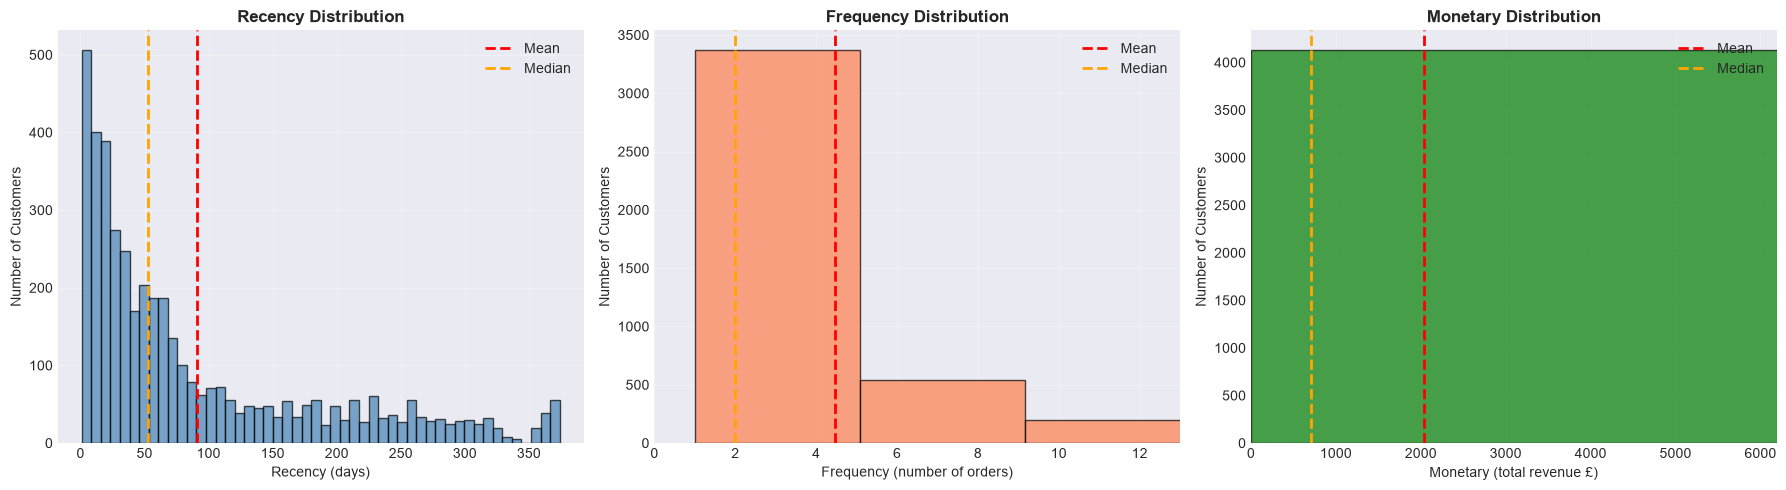


Recency - Mean: 91.2 days, Median: 53.0 days
Frequency - Mean: 4.5 orders, Median: 2.0 orders
Monetary - Mean: £2040.41, Median: £701.62


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm['Recency'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Recency Distribution', fontweight='bold')
axes[0].axvline(rfm['Recency'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(rfm['Recency'].median(), color='orange', linestyle='--', linewidth=2, label='Median')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(rfm['Frequency'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Frequency (number of orders)')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Frequency Distribution', fontweight='bold')
axes[1].set_xlim(0, rfm['Frequency'].quantile(0.95))
axes[1].axvline(rfm['Frequency'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1].axvline(rfm['Frequency'].median(), color='orange', linestyle='--', linewidth=2, label='Median')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].hist(rfm['Monetary'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Monetary (total revenue £)')
axes[2].set_ylabel('Number of Customers')
axes[2].set_title('Monetary Distribution', fontweight='bold')
axes[2].set_xlim(0, rfm['Monetary'].quantile(0.95))
axes[2].axvline(rfm['Monetary'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[2].axvline(rfm['Monetary'].median(), color='orange', linestyle='--', linewidth=2, label='Median')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/rfm_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nRecency - Mean: {rfm['Recency'].mean():.1f} days, Median: {rfm['Recency'].median():.1f} days")
print(f"Frequency - Mean: {rfm['Frequency'].mean():.1f} orders, Median: {rfm['Frequency'].median():.1f} orders")
print(f"Monetary - Mean: £{rfm['Monetary'].mean():.2f}, Median: £{rfm['Monetary'].median():.2f}")


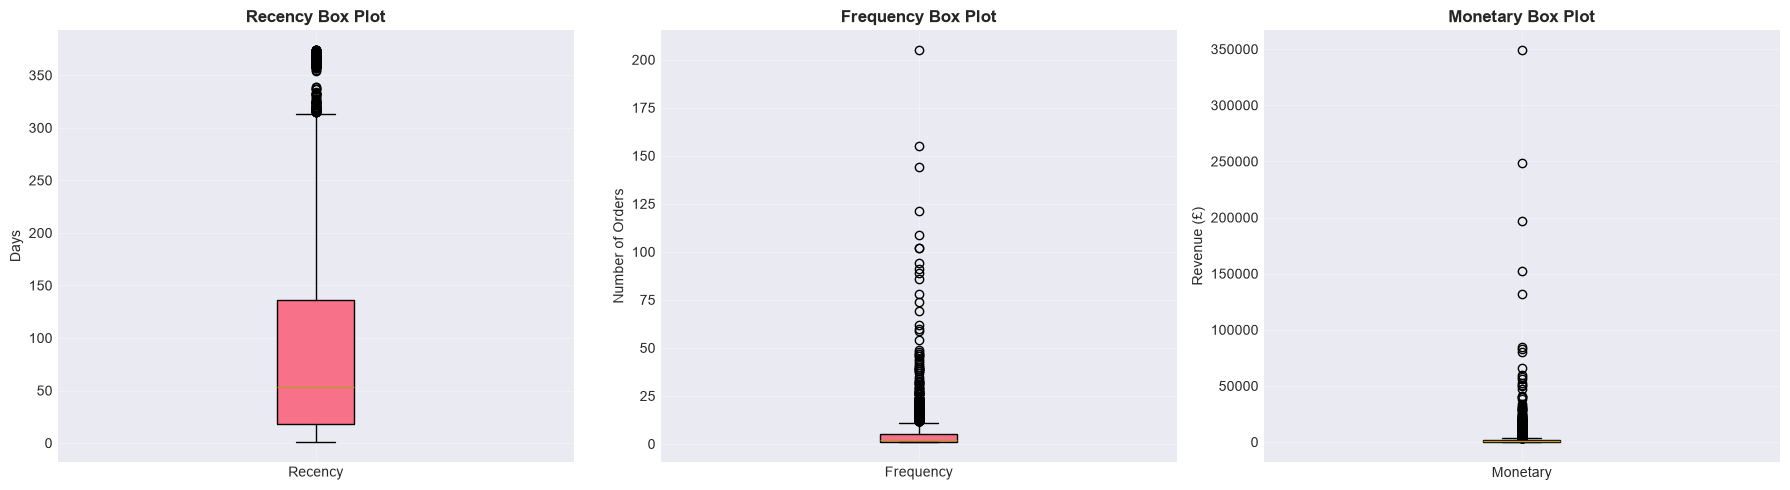

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].boxplot([rfm['Recency']], patch_artist=True)
axes[0].set_xticklabels(['Recency'])
axes[0].set_ylabel('Days')
axes[0].set_title('Recency Box Plot', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].boxplot([rfm['Frequency']], patch_artist=True)
axes[1].set_xticklabels(['Frequency'])
axes[1].set_ylabel('Number of Orders')
axes[1].set_title('Frequency Box Plot', fontweight='bold')
axes[1].grid(alpha=0.3)

axes[2].boxplot([rfm['Monetary']], patch_artist=True)
axes[2].set_xticklabels(['Monetary'])
axes[2].set_ylabel('Revenue (£)')
axes[2].set_title('Monetary Box Plot', fontweight='bold')
axes[2].grid(alpha=0.3)

for ax in axes:
    for patch in ax.artists:
        patch.set_facecolor('lightblue')

plt.tight_layout()
plt.savefig('../reports/figures/rfm_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

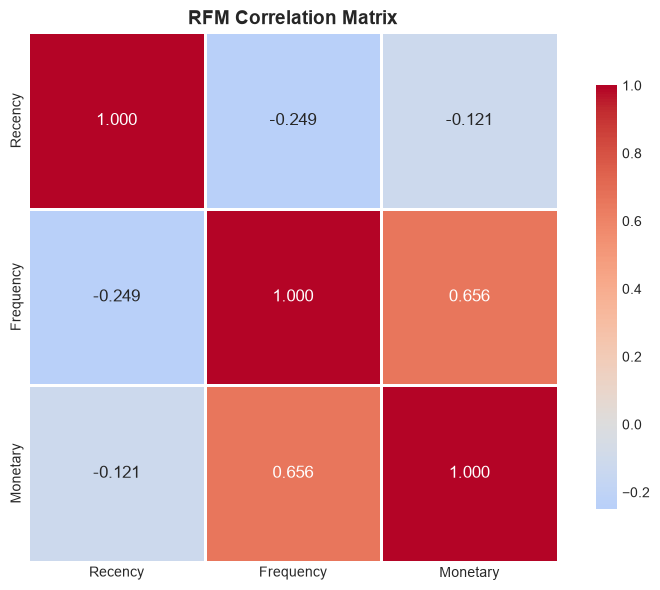

RFM Correlations:
Recency vs Frequency: -0.249
Recency vs Monetary: -0.121
Frequency vs Monetary: 0.656


In [7]:
correlation_matrix = rfm[['Recency', 'Frequency', 'Monetary']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=2, cbar_kws={"shrink": 0.8}, 
            fmt='.3f', annot_kws={'size': 12})
plt.title('RFM Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/rfm_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("RFM Correlations:")
print(f"Recency vs Frequency: {correlation_matrix.loc['Recency', 'Frequency']:.3f}")
print(f"Recency vs Monetary: {correlation_matrix.loc['Recency', 'Monetary']:.3f}")
print(f"Frequency vs Monetary: {correlation_matrix.loc['Frequency', 'Monetary']:.3f}")

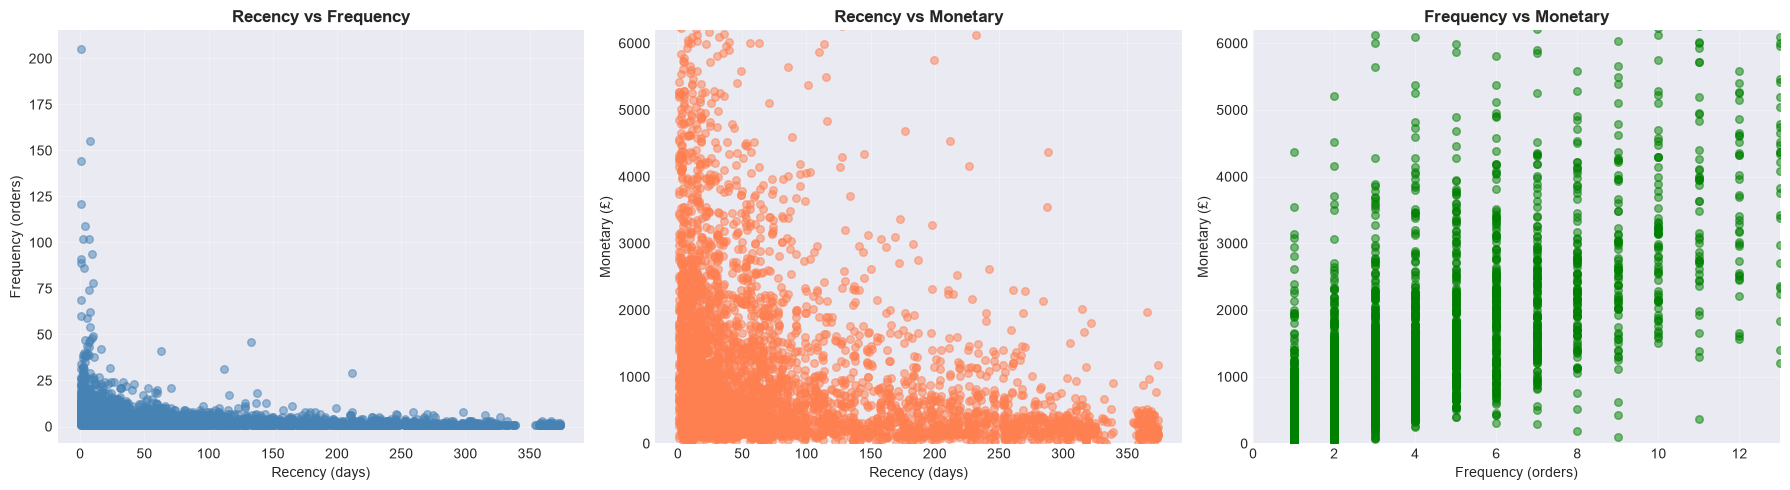

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(rfm['Recency'], rfm['Frequency'], alpha=0.5, s=30, color='steelblue')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Frequency (orders)')
axes[0].set_title('Recency vs Frequency', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].scatter(rfm['Recency'], rfm['Monetary'], alpha=0.5, s=30, color='coral')
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Recency vs Monetary', fontweight='bold')
axes[1].set_ylim(0, rfm['Monetary'].quantile(0.95))
axes[1].grid(alpha=0.3)

axes[2].scatter(rfm['Frequency'], rfm['Monetary'], alpha=0.5, s=30, color='green')
axes[2].set_xlabel('Frequency (orders)')
axes[2].set_ylabel('Monetary (£)')
axes[2].set_title('Frequency vs Monetary', fontweight='bold')
axes[2].set_xlim(0, rfm['Frequency'].quantile(0.95))
axes[2].set_ylim(0, rfm['Monetary'].quantile(0.95))
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/rfm_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
try:
    rfm_scored = analyzer.score_rfm(rfm)
    print(f"RFM scores created for {len(rfm_scored):,} customers")
    print("\nSample of scored RFM data:")
    print(rfm_scored.head(10))
except Exception as e:
    print(f"Error in automatic scoring: {e}")
    print("\nUsing manual scoring method...")
    
    rfm_scored = rfm.copy()
    
    rfm_scored['R_Score'] = pd.qcut(rfm_scored['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')
    rfm_scored['F_Score'] = pd.qcut(rfm_scored['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
    rfm_scored['M_Score'] = pd.qcut(rfm_scored['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
    
    rfm_scored['R_Score'] = rfm_scored['R_Score'].astype(int)
    rfm_scored['F_Score'] = rfm_scored['F_Score'].astype(int)
    rfm_scored['M_Score'] = rfm_scored['M_Score'].astype(int)
    
    rfm_scored['RFM_Score'] = (rfm_scored['R_Score'].astype(str) + 
                               rfm_scored['F_Score'].astype(str) + 
                               rfm_scored['M_Score'].astype(str))
    
    rfm_scored['RFM_Total'] = rfm_scored['R_Score'] + rfm_scored['F_Score'] + rfm_scored['M_Score']
    
    print(f"RFM scores created for {len(rfm_scored):,} customers")
    print("\nSample of scored RFM data:")
    print(rfm_scored.head(10))

rfm_scored.head(10)

RFM scores created for 4,312 customers

Sample of scored RFM data:
   Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0     12346.00      165         11    372.86        2        5        2   
1     12347.00        3          2   1323.32        5        2        4   
2     12348.00       74          1    222.16        2        1        1   
3     12349.00       43          3   2671.14        3        3        5   
4     12351.00       11          1    300.93        5        1        2   
5     12352.00       11          2    343.80        5        2        2   
6     12353.00       44          1    317.76        3        1        2   
7     12355.00      203          1    488.21        1        1        2   
8     12356.00       16          3   3560.30        4        3        5   
9     12357.00       24          2  12079.99        4        2        5   

  RFM_Score  RFM_Total  
0       252          9  
1       524         11  
2       211          4  
3      

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346.00,165,11,372.86,2,5,2,252,9
1,12347.00,3,2,1323.32,5,2,4,524,11
2,12348.00,74,1,222.16,2,1,1,211,4
3,12349.00,43,3,2671.14,3,3,5,335,11
4,12351.00,11,1,300.93,5,1,2,512,8
5,12352.00,11,2,343.80,5,2,2,522,9
6,12353.00,44,1,317.76,3,1,2,312,6
7,12355.00,203,1,488.21,1,1,2,112,4
8,12356.00,16,3,3560.30,4,3,5,435,12
9,12357.00,24,2,12079.99,4,2,5,425,11


In [10]:
rfm_scored = analyzer.score_rfm(rfm)
print(rfm_scored['F_Score'].value_counts().sort_index())

F_Score
1    863
2    862
3    862
4    862
5    863
Name: count, dtype: int64


In [11]:
print("RFM Score Distribution:\n")
for metric in ['R_Score', 'F_Score', 'M_Score']:
    print(f"\n{metric}:")
    print(rfm_scored[metric].value_counts().sort_index())

RFM Score Distribution:


R_Score:
R_Score
1    863
2    862
3    862
4    862
5    863
Name: count, dtype: int64

F_Score:
F_Score
1    863
2    862
3    862
4    862
5    863
Name: count, dtype: int64

M_Score:
M_Score
1    863
2    862
3    862
4    862
5    863
Name: count, dtype: int64


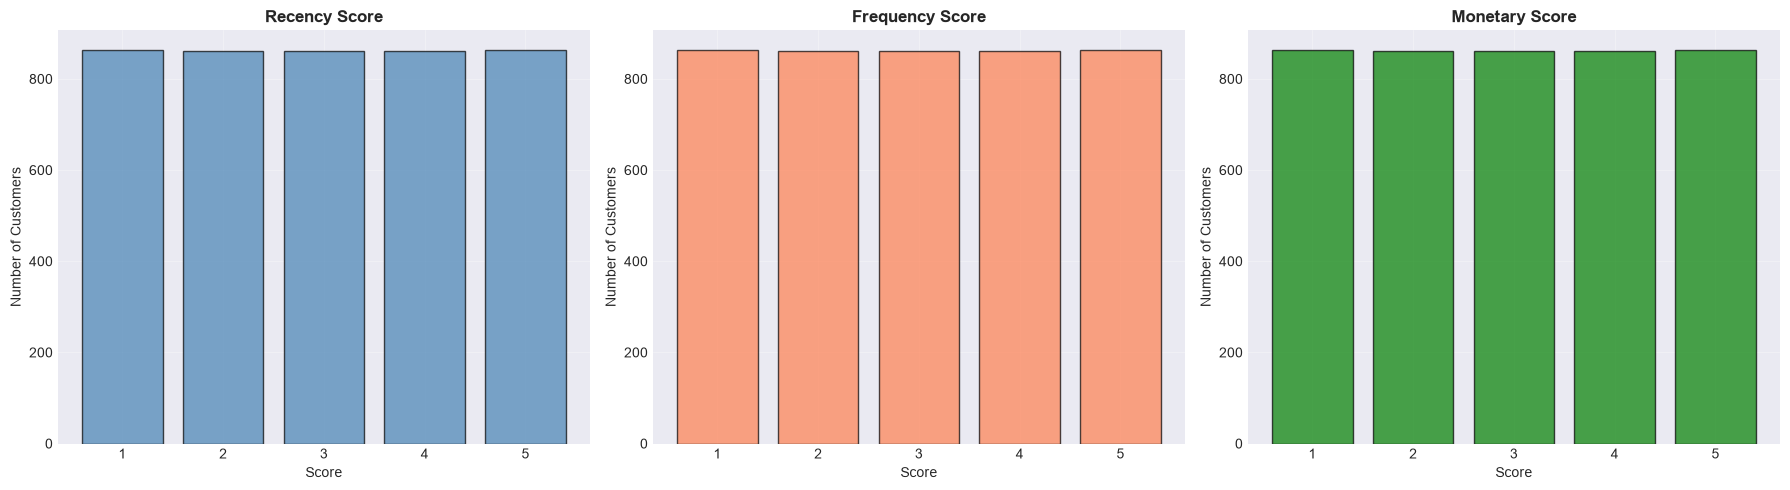

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

score_cols = ['R_Score', 'F_Score', 'M_Score']
colors = ['steelblue', 'coral', 'green']
titles = ['Recency Score', 'Frequency Score', 'Monetary Score']

for i, (col, color, title) in enumerate(zip(score_cols, colors, titles)):
    counts = rfm_scored[col].value_counts().sort_index()
    axes[i].bar(counts.index, counts.values, color=color, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Number of Customers')
    axes[i].set_title(title, fontweight='bold')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/rfm_score_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
additional_features = create_additional_features(df, customer_col='Customer ID')

print(f"Additional features created for {len(additional_features):,} customers")
print("\nAdditional features:")
additional_features.head(10)

Additional features created for 4,312 customers

Additional features:


,Customer ID,Total_Items,Total_Orders,Total_Revenue,Avg_Order_Value,Unique_Products,First_Purchase,Last_Purchase,Avg_Items_Per_Order,Customer_Lifespan_Days,Purchase_Frequency
0,12346.00,70,11,372.86,11.30,26,2009-12-14 08:34:00,2010-06-28 13:53:00,6.36,196,0.06
1,12347.00,828,2,1323.32,18.64,70,2010-10-31 14:20:00,2010-12-07 14:57:00,414.00,37,0.05
2,12348.00,373,1,222.16,11.11,20,2010-09-27 14:59:00,2010-09-27 14:59:00,373.00,0,1.00
3,12349.00,993,3,2671.14,26.19,90,2010-04-29 13:20:00,2010-10-28 08:23:00,331.00,181,0.02
4,12351.00,261,1,300.93,14.33,21,2010-11-29 15:23:00,2010-11-29 15:23:00,261.00,0,1.00
5,12352.00,188,2,343.80,19.10,18,2010-11-12 10:20:00,2010-11-29 10:07:00,94.00,16,0.12
6,12353.00,192,1,317.76,15.89,20,2010-10-27 12:44:00,2010-10-27 12:44:00,192.00,0,1.00
7,12355.00,303,1,488.21,22.19,22,2010-05-21 11:59:00,2010-05-21 11:59:00,303.00,0,1.00
8,12356.00,1825,3,3560.30,42.90,68,2010-10-11 09:42:00,2010-11-24 12:24:00,608.33,44,0.07
9,12357.00,3879,2,12079.99,73.21,165,2010-11-16 10:05:00,2010-11-16 14:29:00,1939.50,0,2.00


In [14]:
customer_features = rfm_scored.merge(additional_features, on='Customer ID', how='left')

customer_features = customer_features.drop(['Total_Revenue'], axis=1)

print(f"Combined features: {len(customer_features):,} customers × {len(customer_features.columns)} features")
print("\nFeature columns:")
for i, col in enumerate(customer_features.columns, 1):
    print(f"{i}. {col}")

customer_features.head()

Combined features: 4,312 customers × 18 features

Feature columns:
1. Customer ID
2. Recency
3. Frequency
4. Monetary
5. R_Score
6. F_Score
7. M_Score
8. RFM_Score
9. RFM_Total
10. Total_Items
11. Total_Orders
12. Avg_Order_Value
13. Unique_Products
14. First_Purchase
15. Last_Purchase
16. Avg_Items_Per_Order
17. Customer_Lifespan_Days
18. Purchase_Frequency


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Total_Items,Total_Orders,Avg_Order_Value,Unique_Products,First_Purchase,Last_Purchase,Avg_Items_Per_Order,Customer_Lifespan_Days,Purchase_Frequency
0,12346.00,165,11,372.86,2,5,2,252,9,70,11,11.30,26,2009-12-14 08:34:00,2010-06-28 13:53:00,6.36,196,0.06
1,12347.00,3,2,1323.32,5,2,4,524,11,828,2,18.64,70,2010-10-31 14:20:00,2010-12-07 14:57:00,414.00,37,0.05
2,12348.00,74,1,222.16,2,1,1,211,4,373,1,11.11,20,2010-09-27 14:59:00,2010-09-27 14:59:00,373.00,0,1.00
3,12349.00,43,3,2671.14,3,3,5,335,11,993,3,26.19,90,2010-04-29 13:20:00,2010-10-28 08:23:00,331.00,181,0.02
4,12351.00,11,1,300.93,5,1,2,512,8,261,1,14.33,21,2010-11-29 15:23:00,2010-11-29 15:23:00,261.00,0,1.00


In [15]:
print("Customer Features Statistics:\n")
customer_features[['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 
                   'Unique_Products', 'Avg_Items_Per_Order']].describe()

Customer Features Statistics:



,Recency,Frequency,Monetary,Avg_Order_Value,Unique_Products,Avg_Items_Per_Order
count,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00
mean,91.17,4.46,2040.41,37.01,63.65,254.62
std,96.86,8.17,8911.76,217.72,85.76,1554.08
min,1.00,1.00,2.95,1.99,1.00,1.00
25%,18.00,1.00,307.19,11.19,17.00,89.00
50%,53.00,2.00,701.62,17.36,38.00,150.89
75%,136.00,5.00,1714.93,24.84,79.25,255.05
max,374.00,205.00,349164.35,10953.50,1741.00,87167.00


In [16]:
top_customers = customer_features.nlargest(20, 'Monetary')[
    ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'RFM_Total', 
     'Avg_Order_Value', 'Unique_Products']
]

print("Top 20 Customers by Monetary Value:\n")
top_customers

Top 20 Customers by Monetary Value:



,Customer ID,Recency,Frequency,Monetary,RFM_Total,Avg_Order_Value,Unique_Products
4183,18102.00,1,89,349164.35,15,556.88,281
1637,14646.00,10,78,248396.50,15,140.10,606
1269,14156.00,7,102,196549.74,15,74.28,1094
1840,14911.00,1,205,152121.22,15,27.32,1741
939,13694.00,9,94,131443.19,15,137.35,654
3744,17511.00,3,31,84541.17,15,89.18,423
1951,15061.00,3,86,83284.38,15,142.61,116
3128,16684.00,15,27,80489.21,14,182.52,124
3177,16754.00,8,29,65500.07,15,467.86,38
4065,17949.00,7,74,60117.60,15,691.01,34


In [17]:
print("Customer Segmentation Preview based on RFM Total Score:\n")

customer_features['Segment_Preview'] = pd.cut(
    customer_features['RFM_Total'],
    bins=[2, 6, 9, 12, 16],
    labels=['Low Value', 'Medium Value', 'High Value', 'VIP'],
    include_lowest=True
)

segment_counts = customer_features['Segment_Preview'].value_counts()

for segment in ['Low Value', 'Medium Value', 'High Value', 'VIP']:
    count = segment_counts.get(segment, 0)
    pct = (count / len(customer_features)) * 100
    print(f"{segment}: {count:,} customers ({pct:.1f}%)")

Customer Segmentation Preview based on RFM Total Score:

Low Value: 1,246 customers (28.9%)
Medium Value: 1,131 customers (26.2%)
High Value: 1,029 customers (23.9%)
VIP: 906 customers (21.0%)


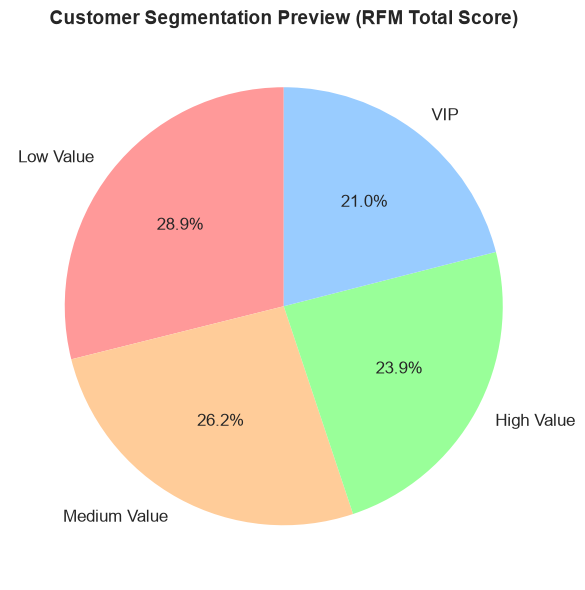

In [18]:
plt.figure(figsize=(10, 6))

segment_counts = customer_features['Segment_Preview'].value_counts()
colors = ['#ff9999', '#ffcc99', '#99ff99', '#99ccff']

plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, textprops={'fontsize': 12})
plt.title('Customer Segmentation Preview (RFM Total Score)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/rfm_segment_preview.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
segment_analysis = customer_features.groupby('Segment_Preview').agg({
    'Customer ID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum'],
    'Avg_Order_Value': 'mean',
    'Unique_Products': 'mean'
}).round(2)

segment_analysis.columns = ['Count', 'Avg_Recency', 'Avg_Frequency', 
                            'Avg_Monetary', 'Total_Revenue', 
                            'Avg_Order_Value', 'Avg_Unique_Products']

print("Segment Analysis:\n")
segment_analysis

Segment Analysis:



,Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Avg_Order_Value,Avg_Unique_Products
Segment_Preview,,,,,,,
Low Value,1246,188.07,1.15,264.55,329627.00,27.07,18.94
Medium Value,1131,84.80,2.08,712.94,806340.07,50.18,37.57
High Value,1029,47.49,4.15,1696.35,1745546.21,35.32,74.25
VIP,906,15.47,12.31,6530.60,5916720.46,36.16,145.65


In [20]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)

customer_features.to_csv('../data/processed/customer_features.csv', index=False)
rfm_scored.to_csv('../data/processed/rfm_scores.csv', index=False)

print("Saved files:")
print("  - data/processed/customer_features.csv")
print("  - data/processed/rfm_scores.csv")

print(f"\nCustomer features shape: {customer_features.shape}")
print(f"RFM scores shape: {rfm_scored.shape}")

Saved files:
  - data/processed/customer_features.csv
  - data/processed/rfm_scores.csv

Customer features shape: (4312, 19)
RFM scores shape: (4312, 9)


In [21]:

rfm_summary = {
    'analysis_date': pd.Timestamp.now().isoformat(),
    'total_customers': int(len(customer_features)),
    'rfm_statistics': {
        'recency': {
            'mean': float(rfm['Recency'].mean()),
            'median': float(rfm['Recency'].median()),
            'std': float(rfm['Recency'].std()),
            'min': float(rfm['Recency'].min()),
            'max': float(rfm['Recency'].max())
        },
        'frequency': {
            'mean': float(rfm['Frequency'].mean()),
            'median': float(rfm['Frequency'].median()),
            'std': float(rfm['Frequency'].std()),
            'min': float(rfm['Frequency'].min()),
            'max': float(rfm['Frequency'].max())
        },
        'monetary': {
            'mean': float(rfm['Monetary'].mean()),
            'median': float(rfm['Monetary'].median()),
            'std': float(rfm['Monetary'].std()),
            'min': float(rfm['Monetary'].min()),
            'max': float(rfm['Monetary'].max())
        }
    },
    'segment_preview': {
        segment: int(count) for segment, count in segment_counts.items()
    },
    'total_features': int(len(customer_features.columns)),
    'features_list': list(customer_features.columns)
}

import json
with open('../reports/rfm_summary.json', 'w') as f:
    json.dump(rfm_summary, f, indent=4)

print("RFM summary saved to reports/rfm_summary.json")

RFM summary saved to reports/rfm_summary.json


In [22]:
print("RFM Feature Engineering Summary:\n")

print(f"Total Customers Analyzed: {len(customer_features):,}")
print(f"Total Features Created: {len(customer_features.columns)}")

print(f"\nRFM Metrics:")
print(f"  Recency: {rfm['Recency'].mean():.1f} days (avg)")
print(f"  Frequency: {rfm['Frequency'].mean():.1f} orders (avg)")
print(f"  Monetary: £{rfm['Monetary'].mean():.2f} (avg)")

print(f"\nSegment Preview:")
for segment in ['Low Value', 'Medium Value', 'High Value', 'VIP']:
    count = segment_counts.get(segment, 0)
    pct = (count / len(customer_features)) * 100
    print(f"  {segment}: {count:,} ({pct:.1f}%)")

print(f"\nFiles Created:")
print(f"  - customer_features.csv ({customer_features.shape[0]} rows × {customer_features.shape[1]} cols)")
print(f"  - rfm_scores.csv ({rfm_scored.shape[0]} rows × {rfm_scored.shape[1]} cols)")
print(f"  - 5 visualization plots")

print("\nReady for K-Means clustering!")

RFM Feature Engineering Summary:

Total Customers Analyzed: 4,312
Total Features Created: 19

RFM Metrics:
  Recency: 91.2 days (avg)
  Frequency: 4.5 orders (avg)
  Monetary: £2040.41 (avg)

Segment Preview:
  Low Value: 1,246 (28.9%)
  Medium Value: 1,131 (26.2%)
  High Value: 1,029 (23.9%)
  VIP: 906 (21.0%)

Files Created:
  - customer_features.csv (4312 rows × 19 cols)
  - rfm_scores.csv (4312 rows × 9 cols)
  - 5 visualization plots

Ready for K-Means clustering!
